In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load MNIST data
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize images to range [0,1]
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

# Add channel dimension (1, 28, 28) for grayscale images
train_images = train_images.reshape(-1, 1, 28, 28)
test_images = test_images.reshape(-1, 1, 28, 28)

# One-hot encode labels
num_classes = 10
train_labels = np.eye(num_classes)[train_labels]
test_labels = np.eye(num_classes)[test_labels]

print("Train Images Shape:", train_images.shape)  # (60000, 1, 28, 28)
print("Train Labels Shape:", train_labels.shape)  # (60000, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train Images Shape: (60000, 1, 28, 28)
Train Labels Shape: (60000, 10)


In [10]:
class Conv2D:
    def __init__(self, input_shape, kernel_size, num_filters, stride=1, padding=0):
        self.input_shape = input_shape  # (channels, height, width)
        self.kernel_size = kernel_size
        self.num_filters = num_filters
        self.stride = stride
        self.padding = padding

        input_depth, input_height, input_width = input_shape
        self.output_height = (input_height - kernel_size + 2 * padding) // stride + 1
        self.output_width = (input_width - kernel_size + 2 * padding) // stride + 1
        self.output_shape = (num_filters, self.output_height, self.output_width)

        self.kernels = np.random.randn(num_filters, input_depth, kernel_size, kernel_size) * 0.1
        self.biases = np.zeros((num_filters, 1, 1))

    def forward(self, input_data):
        self.input_data = np.pad(input_data, ((0, 0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')
        output = np.zeros(self.output_shape)

        for f in range(self.num_filters):
            for i in range(0, self.output_height, self.stride):
                for j in range(0, self.output_width, self.stride):
                    region = self.input_data[:, i:i+self.kernel_size, j:j+self.kernel_size]
                    output[f, i, j] = np.sum(region * self.kernels[f]) + self.biases[f].item()

        return output

class ReLU:
    def forward(self, input_data):
        return np.maximum(0, input_data)

class MaxPool2D:
    def __init__(self, pool_size, stride):
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, input_data):
        c, h, w = input_data.shape
        out_h = h // self.pool_size
        out_w = w // self.pool_size
        output = np.zeros((c, out_h, out_w))

        for i in range(out_h):
            for j in range(out_w):
                region = input_data[:, i*self.pool_size:(i+1)*self.pool_size, j*self.pool_size:(j+1)*self.pool_size]
                output[:, i, j] = np.max(region, axis=(1, 2))

        return output

class FullyConnected:
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size) * 0.1
        self.biases = np.zeros(output_size)

    def forward(self, input_data):
        self.input_data = input_data.flatten()  # Flatten input before FC layer
        return np.dot(self.weights, self.input_data) + self.biases

class Softmax:
    def forward(self, input_data):
        exp_values = np.exp(input_data - np.max(input_data))  # Numerical stability
        return exp_values / np.sum(exp_values)

class SimpleCNN:
    def __init__(self):
        self.conv1 = Conv2D(input_shape=(1, 28, 28), kernel_size=3, num_filters=8)
        self.relu1 = ReLU()
        self.pool1 = MaxPool2D(pool_size=2, stride=2)

        conv_output_size = 8 * 13 * 13  # (8 filters, 13x13 output)
        self.fc = FullyConnected(input_size=conv_output_size, output_size=10)
        self.softmax = Softmax()

    def forward(self, x):
        x = self.conv1.forward(x)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)
        x = self.fc.forward(x)
        x = self.softmax.forward(x)
        return x

In [11]:
def cross_entropy_loss(predictions, labels):
    return -np.sum(labels * np.log(predictions + 1e-8))  # Small value to prevent log(0)

def compute_accuracy(model, images, labels):
    correct = 0
    for i in range(len(images)):
        output = model.forward(images[i])
        if np.argmax(output) == np.argmax(labels[i]):
            correct += 1
    return correct / len(images)

# Train CNN
def train(model, images, labels, epochs=3, lr=0.01):
    for epoch in range(epochs):
        total_loss = 0
        for i in range(len(images)):
            output = model.forward(images[i])
            loss = cross_entropy_loss(output, labels[i])
            total_loss += loss

            # Backpropagation (Manual SGD updates for simplicity)
            error = output - labels[i]

            # Update fully connected weights
            model.fc.weights -= lr * np.outer(error, model.fc.input_data)
            model.fc.biases -= lr * error

        acc = compute_accuracy(model, images[:1000], labels[:1000])  # Check accuracy on small set
        print(f"Epoch {epoch+1}, Loss: {total_loss:.3f}, Accuracy: {acc:.3f}")

cnn = SimpleCNN()
train(cnn, train_images[:1000], train_labels[:1000], epochs=3, lr=0.01)

Epoch 1, Loss: 1688.510, Accuracy: 0.727
Epoch 2, Loss: 1025.039, Accuracy: 0.827
Epoch 3, Loss: 786.313, Accuracy: 0.850


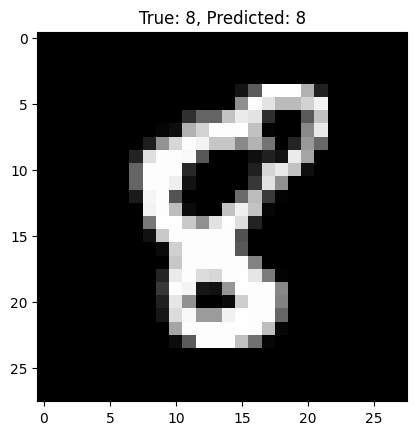

In [12]:
sample_idx = np.random.randint(0, len(test_images))
sample_image = test_images[sample_idx]
sample_label = np.argmax(test_labels[sample_idx])

predicted = np.argmax(cnn.forward(sample_image))

import matplotlib.pyplot as plt
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"True: {sample_label}, Predicted: {predicted}")
plt.show()

In [17]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import google.colab.output
import ipywidgets as widgets
from IPython.display import display, clear_output
import PIL.Image

# Create a blank white canvas (28x28)
canvas_size = 280  # 10x scale for better drawing experience
canvas = np.ones((canvas_size, canvas_size), dtype=np.uint8) * 255
drawing = False

# Mouse event handler
def draw_circle(event, x, y, flags, param):
    global drawing, canvas
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        cv2.circle(canvas, (x, y), 10, (0, 0, 0), -1)  # Draw with a 10px brush
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False

# Display interactive OpenCV window
def show_canvas():
    cv2.namedWindow("Draw a Digit", cv2.WINDOW_NORMAL)
    cv2.setMouseCallback("Draw a Digit", draw_circle)
    while True:
        cv2.imshow("Draw a Digit", canvas)
        key = cv2.waitKey(1) & 0xFF
        if key == 27:  # Press 'Esc' to exit
            break
    cv2.destroyAllWindows()

# Function to clear canvas
def clear_canvas(_=None):
    global canvas
    canvas[:] = 255
    cv2_imshow(canvas)

# Function to preprocess image and predict digit
def predict(_=None):
    global canvas
    img_resized = cv2.resize(canvas, (28, 28), interpolation=cv2.INTER_AREA)
    img_resized = img_resized / 255.0  # Normalize pixel values
    img_resized = img_resized[np.newaxis, np.newaxis, :, :]  # Shape (1,1,28,28) for CNN

    output, _ = cnn.forward(img_resized)  # Run through CNN
    prediction = np.argmax(output)

    clear_output(wait=True)
    print(f"🟢 Predicted Digit: {prediction}")
    cv2_imshow(img_resized * 255)  # Show the resized 28x28 image

# Display buttons
display(widgets.Button(description="Clear", button_style="danger", on_click=clear_canvas))
display(widgets.Button(description="Predict", button_style="success", on_click=predict))

# Start interactive drawing
show_canvas()

Button(button_style='danger', description='Clear', style=ButtonStyle())

Button(button_style='success', description='Predict', style=ButtonStyle())

error: OpenCV(4.11.0) /io/opencv/modules/highgui/src/window.cpp:1284: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvNamedWindow'
